In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv("../data/processed/coffee_sales_clean.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8593 entries, 0 to 8592
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    8593 non-null   str    
 1   Item              8593 non-null   str    
 2   Quantity          8593 non-null   float64
 3   Price Per Unit    8593 non-null   float64
 4   Total Spent       8593 non-null   float64
 5   Payment Method    8593 non-null   str    
 6   Location          8593 non-null   str    
 7   Transaction Date  8593 non-null   str    
 8   Month             8593 non-null   str    
 9   Day               8593 non-null   str    
dtypes: float64(3), str(7)
memory usage: 671.5 KB


In [4]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

In [5]:
# Productos con más ingresos
top_products = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).head(5)
print(top_products)

Item
Salad       16575.0
Sandwich    13068.0
Smoothie    12776.0
Juice       10023.0
Cake         9834.0
Name: Total Spent, dtype: float64


In [ ]:
# Tendencia en el tiempo por mes
order = [ "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["Month"] = pd.Categorical(df["Month"], categories=order, ordered=True)
daily_sales = df.groupby("Month", as_index=False)["Total Spent"].sum()
daily_sales = daily_sales.rename(columns={
    "Month": "Mes",
    "Total Spent": "Ventas"
})
fig = px.line(daily_sales, x="Mes", y="Ventas", title="Ventas por meses")
fig.show()

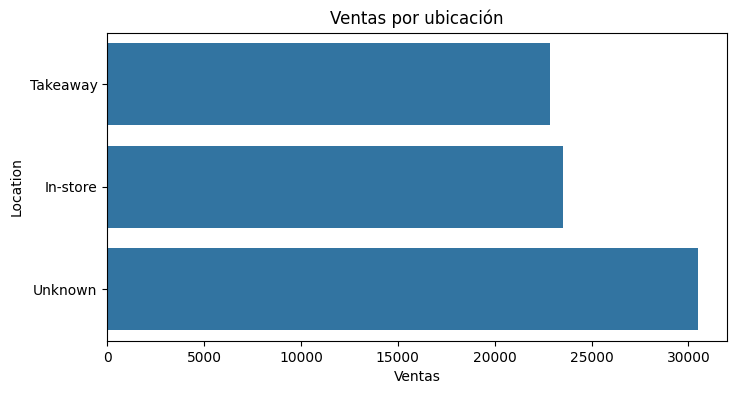

In [6]:
# Tienda con mas ingresos
location_sales = df.groupby("Location")["Total Spent"].sum().sort_values()
plt.figure(figsize=(8, 4))
sns.barplot(x=location_sales.values, y=location_sales.index)
plt.title("Ventas por ubicación")
plt.xlabel("Ventas")
plt.show()

In [ ]:
# Días con mayor ventas
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
total_per_day = df.groupby("Day")["Total Spent"].sum().reindex(days_order).reset_index()

fig = px.bar(
    total_per_day,
    x="Day",
    y="Total Spent",
    title="Ventas por dia de la semana",
    text="Total Spent",
    color_continuous_scale="Viridis"
)

fig.show()